In [1]:
import brian2 as b2
print(b2.__version__)

2.9.0


WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/ (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


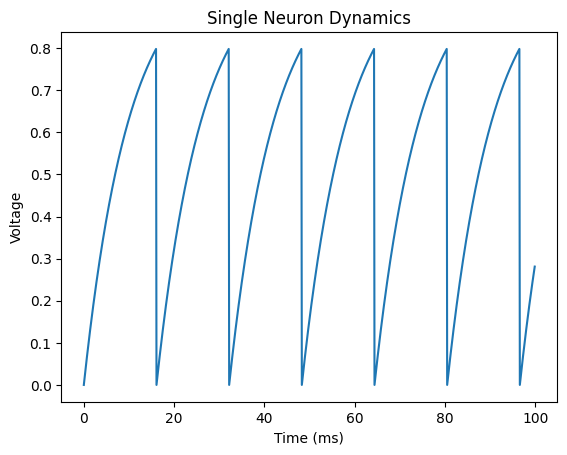

In [2]:
from brian2 import *
import matplotlib.pyplot as plt

# Simulation time
duration = 100*ms

# Neuron equation (simple)
eqs = '''
dv/dt = (1 - v)/tau : 1
tau : second
'''

# Create neuron
G = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')

# Initial conditions
G.v = 0
G.tau = 10*ms

# Record voltage
M = StateMonitor(G, 'v', record=True)

# Run simulation
run(duration)

# Plot
plt.plot(M.t/ms, M.v[0])
plt.xlabel('Time (ms)')
plt.ylabel('Voltage')
plt.title('Single Neuron Dynamics')
plt.show()